## Train a simple convnet on the Fashion MNIST dataset

In this, we will see how to deal with image data and train a convnet for image classification task.

### Load the  `fashion_mnist`  dataset

** Use keras.datasets to load the dataset **

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import keras
from keras.datasets import mnist
from tensorflow.keras.models import Sequential
from sklearn import metrics
import matplotlib.pyplot as plt
%matplotlib inline

Using TensorFlow backend.


In [2]:
from keras.datasets import fashion_mnist
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

4423680/4422102 [==============================] - 0s 0us/step


### Find no.of samples are there in training and test datasets

In [3]:
y_train.shape

(60000,)

In [4]:
y_test.shape

(10000,)

In [0]:
# Number of samples in training dataset = 60000
# Number of samples in test dataset = 10000

### Find dimensions of an image in the dataset

In [6]:
print('x_train shape =',x_train.shape)
print('y_train shape =',y_train.shape)
print('x_test shape =',x_test.shape)
print('y_test shape =',y_test.shape)

x_train shape = (60000, 28, 28)
y_train shape = (60000,)
x_test shape = (10000, 28, 28)
y_test shape = (10000,)


### Convert train and test labels to one hot vectors

** check `keras.utils.to_categorical()` **

In [7]:
y_train

array([9, 0, 0, ..., 3, 0, 5], dtype=uint8)

In [0]:
# convert class vectors to binary class matrices for keras
num_classes = 10
y_train = tf.keras.utils.to_categorical(y_train, num_classes)
y_test = tf.keras.utils.to_categorical(y_test, num_classes)

In [9]:
y_train[0]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 1.], dtype=float32)

### Normalize both the train and test image data from 0-255 to 0-1

In [0]:
#x_train[0]

In [0]:
# # normalize inputs from 0-255 to 0-1
x_train = x_train/255
x_test = x_test/255

### Reshape the data from 28x28 to 28x28x1 to match input dimensions in Conv2D layer in keras

In [0]:
x_train = x_train.reshape(60000,28,28,1)
x_test = x_test.reshape(10000,28,28,1)

In [13]:
print(x_train.shape)
print(x_test.shape)

(60000, 28, 28, 1)
(10000, 28, 28, 1)


### Import the necessary layers from keras to build the model

In [0]:
from tensorflow.keras.layers import Dense,Dropout,Activation,Flatten
from tensorflow.keras.layers import Conv2D,MaxPooling2D

### Build a model 

** with 2 Conv layers having `32 3x3 filters` in both convolutions with `relu activations` and `flatten` before passing the feature map into 2 fully connected layers (or Dense Layers) having 128 and 10 neurons with `relu` and `softmax` activations respectively. Now, using `categorical_crossentropy` loss with `adam` optimizer train the model with early stopping `patience=5` and no.of `epochs=10`. **

In [15]:
model=Sequential()

#Add first convolutional layer
model.add(Conv2D(32,kernel_size=(3,3),input_shape=(28,28,1),activation='relu'))

#Add second convolutional layer
model.add(Conv2D(32, kernel_size=(3,3), activation='relu'))

#Flatten the output
model.add(Flatten())

# Add Fully connected Layer with 128 neurons and relu activation
model.add(Dense(128,activation='relu'))

# Add Fully connected Layer with 10 neurons and softmax activation
model.add(Dense(10,activation='softmax'))

W0818 10:37:26.604521 139938569000832 deprecation.py:506] From /usr/local/lib/python3.6/dist-packages/tensorflow/python/ops/init_ops.py:1251: calling VarianceScaling.__init__ (from tensorflow.python.ops.init_ops) with dtype is deprecated and will be removed in a future version.
Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor


### Now, to the above model add `max` pooling layer of `filter size 2x2` and `dropout` layer with `p=0.25` after the 2 conv layers and run the model

In [0]:
model=Sequential()

# Add first convolutional layer
model.add(Conv2D(32,kernel_size=(3,3),input_shape=(28,28,1),activation='relu'))

# Add second convolutional layer
model.add(Conv2D(32, kernel_size=(3,3), activation='relu'))

# Add MaxPooling layer
model.add(MaxPooling2D(pool_size=(2,2)))

# Add Dropout layer
model.add(Dropout(0.25))

# Flatten the output
model.add(Flatten())

# Add Fully connected Layer with 128 neurons and relu activation
model.add(Dense(128,activation='relu'))

# Add Fully connected Layer with 10 neurons and softmax activation
model.add(Dense(10,activation='softmax'))

### Now, to the above model, lets add Data Augmentation 

### Import the ImageDataGenrator from keras and fit the training images

In [0]:
# datagen = tf.keras.preprocessing.image.ImageDataGenerator(
#     featurewise_center=True,
#     featurewise_std_normalization=True,
#     rotation_range=20,
#     width_shift_range=0.2,
#     height_shift_range=0.2,
#     horizontal_flip=True)
datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True)

datagen.fit(x_train)

#### Showing 5 versions of the first image in training dataset using image datagenerator.flow()

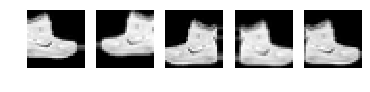

In [18]:
from matplotlib import pyplot as plt
gen = datagen.flow(x_train[0:1], batch_size=1)
for i in range(1, 6):
    plt.subplot(1,5,i)
    plt.axis("off")
    plt.imshow(gen.next().squeeze(), cmap='gray')
    plt.plot()
plt.show()

### Run the above model using fit_generator()

In [0]:
#compile model using accuracy to measure model performance
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [20]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_2 (Conv2D)            (None, 26, 26, 32)        320       
_________________________________________________________________
conv2d_3 (Conv2D)            (None, 24, 24, 32)        9248      
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 12, 12, 32)        0         
_________________________________________________________________
dropout (Dropout)            (None, 12, 12, 32)        0         
_________________________________________________________________
flatten_1 (Flatten)          (None, 4608)              0         
_________________________________________________________________
dense_2 (Dense)              (None, 128)               589952    
_________________________________________________________________
dense_3 (Dense)              (None, 10)               

In [21]:
# fits the model on batches with real-time data augmentation:
model.fit_generator(datagen.flow(x_train, y_train, batch_size=32),validation_data=datagen.flow(x_test,y_test),steps_per_epoch=x_train.shape[0]/32, epochs=10)

Epoch 1/10
1875/1875 [==============================] - 25s 13ms/step - loss: 0.7410 - acc: 0.7228 - val_loss: 0.6115 - val_acc: 0.7693
Epoch 2/10
1875/1875 [==============================] - 21s 11ms/step - loss: 0.5480 - acc: 0.7938 - val_loss: 0.5334 - val_acc: 0.8003
Epoch 3/10
1875/1875 [==============================] - 21s 11ms/step - loss: 0.4867 - acc: 0.8176 - val_loss: 0.4650 - val_acc: 0.8289
Epoch 4/10
1875/1875 [==============================] - 21s 11ms/step - loss: 0.4472 - acc: 0.8317 - val_loss: 0.4371 - val_acc: 0.8399
Epoch 5/10
1875/1875 [==============================] - 21s 11ms/step - loss: 0.4249 - acc: 0.8406 - val_loss: 0.4312 - val_acc: 0.8389
Epoch 6/10
1875/1875 [==============================] - 20s 11ms/step - loss: 0.4041 - acc: 0.8487 - val_loss: 0.3992 - val_acc: 0.8514
Epoch 7/10
1875/1875 [==============================] - 20s 11ms/step - loss: 0.3906 - acc: 0.8540 - val_loss: 0.3865 - val_acc: 0.8546
Epoch 8/10
1875/1875 [==========================

###  Report the final train and validation accuracy

In [0]:
# Train Accuracy from above fit generator - 0.87

In [0]:
# Test Accuracy from above fit generator - 0.86

## **DATA AUGMENTATION ON CIFAR10 DATASET**

One of the best ways to improve the performance of a Deep Learning model is to add more data to the training set. Aside from gathering more instances from the wild that are representative of the distinction task, we want to develop a set of methods that enhance the data we already have. There are many ways to augment existing datasets and produce more robust models. In the image domain, these are done to utilize the full power of the convolutional neural network, which is able to capture translational invariance. This translational invariance is what makes image recognition such a difficult task in the first place. You want the dataset to be representative of the many different positions, angles, lightings, and miscellaneous distortions that are of interest to the vision task.

### **Import neessary libraries for data augmentation**

In [0]:
import keras
import tensorflow as tf
from keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten
from tensorflow.keras.layers import Conv2D, MaxPooling2D

### **Load CIFAR10 dataset**

In [0]:
from keras.datasets import cifar10

In [24]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

170500096/170498071 [==============================] - 6s 0us/step


In [25]:
print('x_train shape =',x_train.shape)
print('y_train shape =',y_train.shape)
print('x_test shape =',x_test.shape)
print('y_test shape =',y_test.shape)

x_train shape = (50000, 32, 32, 3)
y_train shape = (50000, 1)
x_test shape = (10000, 32, 32, 3)
y_test shape = (10000, 1)


### **Create a data_gen funtion to genererator with image rotation,shifting image horizontally and vertically with random flip horizontally.**

In [0]:
datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    featurewise_center=True,
    featurewise_std_normalization=True,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True)

### **Prepare/fit the generator.**

In [0]:
datagen.fit(x_train)

### **Generate 5 images for 1 of the image of CIFAR10 train dataset.**

W0818 10:42:28.456527 139938569000832 image.py:648] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
W0818 10:42:28.472710 139938569000832 image.py:648] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
W0818 10:42:28.488116 139938569000832 image.py:648] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
W0818 10:42:28.504749 139938569000832 image.py:648] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
W0818 10:42:28.520140 139938569000832 image.py:648] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


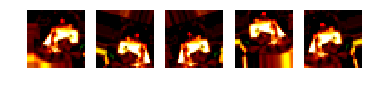

In [28]:
from matplotlib import pyplot as plt
gen = datagen.flow(x_train[0:1], batch_size=1)
for i in range(1, 6):
    plt.subplot(1,5,i)
    plt.axis("off")
    plt.imshow(gen.next().squeeze())
    plt.plot()
plt.show()